# Análisis Exploratorio de Datos (EDA)



In [1]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import bases

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cargar datos
print("Cargando datos principales...")
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
traslados = bases.reconstruir_traslados(df_pacientes)
print("Pacientes y traslados cargados.")


# Geografia
print("Cargando datos geográficos...")
hosp_coords = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
municipios = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
municipios_amba = municipios[
    municipios["in1"].astype(str).str.startswith(("0"))
]
amba_partidos_caso = [
    "QUILMES", "ALMIRANTE BROWN",
    "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]
municipios_amba = municipios_amba[municipios_amba["nam_limpio"].isin(
    amba_partidos_caso)]

print("Datos geográficos cargados.")

Cargando datos principales...
Pacientes y traslados cargados.
Cargando datos geográficos...
Datos geográficos cargados.


In [3]:
df_pacientes

## ACTUALIZAR EL DATASET

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Asistencia Respiratoria Mecánica,Motivo,Operación,Fecha egreso,Última actualización,Pasó por Críticas,Pasó por Intermedias,Pasó por Generales,Duracion días,murio
0,1,EL CRUCE,Mariano,NaT,sospechosos,criticas,sospechosos,criticas,NaN,NaN,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,no,no,NaN,False
1,1,EL CRUCE,12345,NaT,sospechosos,intermedias,sospechosos,criticas,NaN,40,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,si,no,NaN,False
2,1,EL CRUCE,24698750,2020-05-10 12:11:05,sospechosos,criticas,sospechosos,criticas,femenino,44,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,no,no,NaN,False
3,1,EL CRUCE,1001,2020-05-28 12:11:05,ocupadas_covid,intermedias,ocupadas_covid,intermedias,masculino,49,...,NaN,alta-domiciliaria,egreso,2020-06-09 12:11:05,2020-07-21 14:34:40,no,si,no,12.0,False
4,1,EL CRUCE,1002,2020-05-15 12:11:05,ocupadas_covid,criticas,ocupadas_covid,intermedias,femenino,NaN,...,NaN,NaN,NaN,NaT,2020-07-21 14:34:40,si,si,no,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29692,380,MÓDULO HOSPITALARIO 8 - LZ,EO81,2022-01-14 12:11:29,ocupadas_covid,criticas,ocupadas_covid,criticas,masculino,73,...,322,NaN,NaN,NaT,2022-01-31 09:51:06,si,no,no,NaN,False
29693,380,MÓDULO HOSPITALARIO 8 - LZ,VO29,2022-01-30 12:11:29,ocupadas_covid,criticas,ocupadas_covid,criticas,masculino,76,...,NaN,NaN,NaN,NaT,2022-01-31 09:51:49,si,no,no,NaN,False
29694,380,MÓDULO HOSPITALARIO 8 - LZ,NS51,2022-01-22 12:11:29,ocupadas_covid,intermedias,ocupadas_covid,intermedias,NaN,75,...,NaN,NaN,NaN,NaT,2022-01-31 09:52:38,no,si,no,NaN,False
29695,380,MÓDULO HOSPITALARIO 8 - LZ,GU70,2022-01-24 12:11:29,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,37,...,NaN,NaN,NaN,NaT,2022-01-31 09:53:21,no,si,no,NaN,False


In [4]:
(len(traslados)/len(df_pacientes))*100

5.9368265086206895

In [5]:
df_pacientes["Nombre Hospital"].unique()

<StringArray>
[                   'EL CRUCE',                   'MI PUEBLO',
  'MÓDULO HOSPITALARIO 11- FV',                       'OLLER',
                     'IRIARTE', 'MÓDULO HOSPITALARIO 10 - QU',
              'LUCIO MELÉNDEZ',                    'OÑATIVIA',
 'MÓDULO HOSPITALARIO  9 - AB',                'EVITA PUEBLO',
                  'UPA 5 - AB',                 'UPA 11 - FV',
                 'UPA 17 - QU',                 'UPA 10 - BE',
  'MÓDULO HOSPITALARIO 8 - LZ']
Length: 15, dtype: str

## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

Registros luego de filtros: 1763
Hospitales origen únicos: 13
Hospitales destino únicos: 13
Nodos en red: 14
Aristas en red: 51
Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


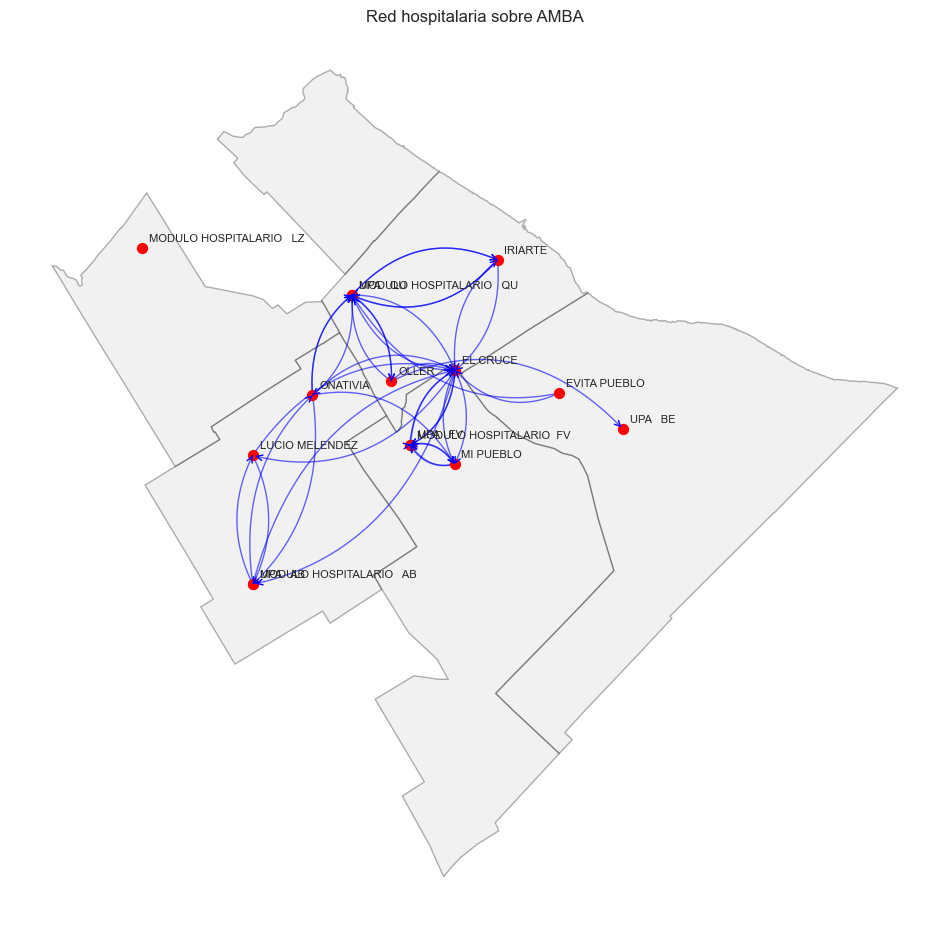

In [6]:
# Generar red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames con curvas
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria_curva(G, hosp_coords, curva_base=0.3)

# Graficar sobre AMBA
bases.plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

In [7]:
#### direccionar
#### cuurvadas
#### elegir sistema para los upas

### 1.2 Total de traslados

In [8]:
# Resumen de traslados
res_tras = bases.resumen_traslados(traslados, imprimir=True)

Total de traslados: 1763
Cantidad de hospitales únicos: 13


### 1.3 Cantidad de traslados en función del tiempo

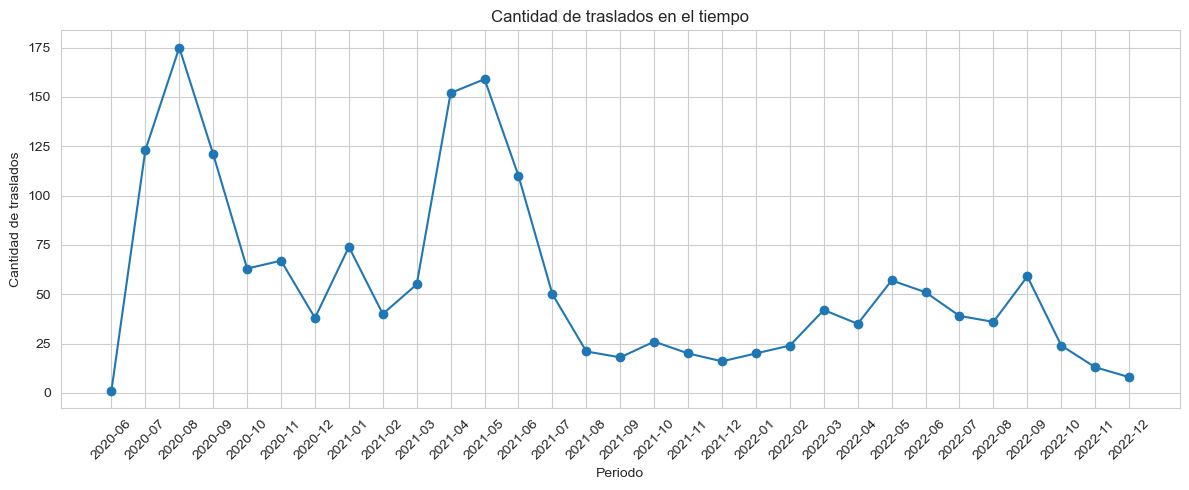

Fecha egreso
2020-06      1
2020-07    123
2020-08    175
2020-09    121
2020-10     63
2020-11     67
2020-12     38
2021-01     74
2021-02     40
2021-03     55
2021-04    152
2021-05    159
2021-06    110
2021-07     50
2021-08     21
2021-09     18
2021-10     26
2021-11     20
2021-12     16
2022-01     20
2022-02     24
2022-03     42
2022-04     35
2022-05     57
2022-06     51
2022-07     39
2022-08     36
2022-09     59
2022-10     24
2022-11     13
2022-12      8
dtype: int64

In [9]:
bases.traslados_en_el_tiempo(traslados, freq="M")

### 1.4 Top de flujos entre hospitales (Caminos más frecuentes)

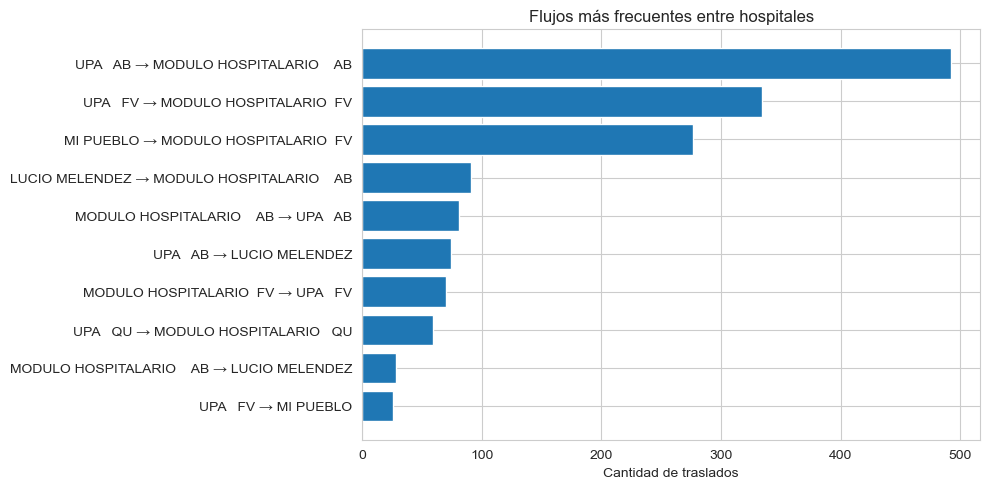

,Nombre Hospital,Hospital siguiente,cantidad
42,UPA AB,MODULO HOSPITALARIO AB,492
46,UPA FV,MODULO HOSPITALARIO FV,334
17,MI PUEBLO,MODULO HOSPITALARIO FV,277
14,LUCIO MELENDEZ,MODULO HOSPITALARIO AB,91
22,MODULO HOSPITALARIO AB,UPA AB,81
41,UPA AB,LUCIO MELENDEZ,74
30,MODULO HOSPITALARIO FV,UPA FV,70
48,UPA QU,MODULO HOSPITALARIO QU,59
20,MODULO HOSPITALARIO AB,LUCIO MELENDEZ,28
45,UPA FV,MI PUEBLO,26


In [10]:
bases.top_flujos_hospitales(traslados, top_n=10)

### 1.5 Métricas de la red (Grafos)

In [11]:
bases.metricas_red(G, top_n=10)

Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.461538     0.481838        104   
11                   ONATIVIA           0.692308     0.226496          6   
10                   UPA   QU           0.538462     0.199786          7   
12                      OLLER           0.384615     0.193376          4   
4   MODULO HOSPITALARIO    AB           0.692308     0.122863        598   
5    MODULO HOSPITALARIO   QU           0.846154     0.057692         72   
3                   MI PUEBLO           0.538462     0.042735         40   
1                     IRIARTE           0.461538     0.000000         18   
2              LUCIO MELENDEZ           0.461538     0.000000        103   
6     MODULO HOSPITALARIO  FV           0.461538     0.000000        618   

    out_degree  
0           22  
11          31  
10          63  
12           3  
4          114  
5           39  
3          3

,hospital,degree_centrality,betweenness,in_degree,out_degree
0,EL CRUCE,1.461538,0.481838,104,22
11,ONATIVIA,0.692308,0.226496,6,31
10,UPA QU,0.538462,0.199786,7,63
12,OLLER,0.384615,0.193376,4,3
4,MODULO HOSPITALARIO AB,0.692308,0.122863,598,114
5,MODULO HOSPITALARIO QU,0.846154,0.057692,72,39
3,MI PUEBLO,0.538462,0.042735,40,302
1,IRIARTE,0.461538,0.000000,18,18
2,LUCIO MELENDEZ,0.461538,0.000000,103,118
6,MODULO HOSPITALARIO FV,0.461538,0.000000,618,101


In [12]:
### Quizas poner par a par
# pagerank

## 2. Trayectorias de Paciente

### 2.1 Cantidad de traslados para cada persona (promedio y desvío, junto a distribución)

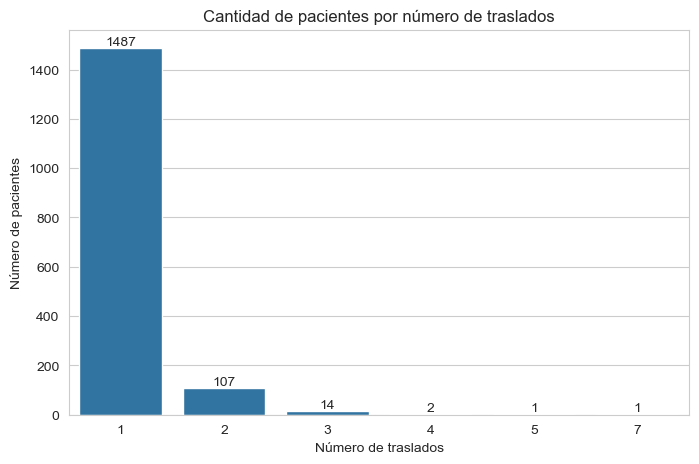

Promedio de traslados por paciente: 1.0936724565756824
Desvío estándar: 0.36857928377450805


In [13]:
# Distribución de traslados por paciente
conteo_tras_paciente, stats_tras_paciente = bases.distribucion_traslados_paciente(traslados, col_id="Id", valores=[1, 2, 3, 4, 5, 6, 7], graficar=True)

In [14]:
## que paso con estos 3?
## reconstruir estos 3

# incluir los ingresos como porcentaje. escala logaritmica

# PROBABILIDAD DE TENER UN TRASLADO MAS DADO LA CANTIDAD DE TRASLADOS QUE TUVISTE

# Cuantos de esos tambien tienen como lo que tuviste

### 2.2 Tiempo dentro del sistema por persona

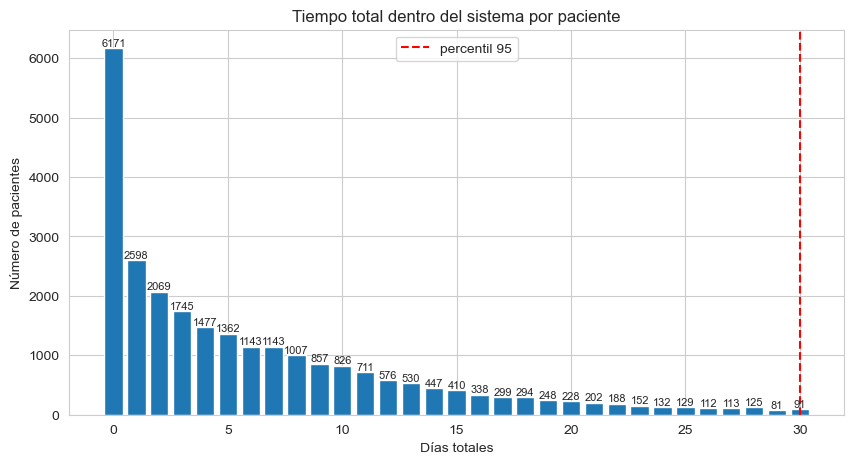

In [15]:
# Tiempo en el sistema por persona
tiempo_sis, limite_tiempo = bases.tiempo_total_paciente(df_pacientes, col_id="Id", col_dias="Duracion días", max_dias=100, quantile_outlier=0.95, graficar=True)

In [16]:
print("n pacientes:", len(tiempo_sis))
print("min:", tiempo_sis.min())
print("max:", tiempo_sis.max())
print("valores:", tiempo_sis.value_counts().head(10))

n pacientes: 27100
min: 0.0
max: 100.0
valores: Duracion días
0.0    6171
1.0    2598
2.0    2069
3.0    1745
4.0    1477
5.0    1362
6.0    1143
7.0    1143
8.0    1007
9.0     857
Name: count, dtype: int64


In [17]:
# un grafico grande y te vas quedando con info
# ir bajandolo a temas

## 3. Análisis Descriptivo por Hospital

### 3.1 Traslados por hospital

Top 10 hospitales que derivan más pacientes:


,traslados_out,traslados_in
UPA AB,575.0,109.0
UPA FV,374.0,83.0
MI PUEBLO,302.0,40.0
LUCIO MELENDEZ,118.0,103.0
MODULO HOSPITALARIO AB,114.0,598.0
MODULO HOSPITALARIO FV,101.0,618.0
UPA QU,63.0,7.0
MODULO HOSPITALARIO QU,39.0,72.0
ONATIVIA,31.0,6.0
EL CRUCE,22.0,104.0



Top 10 hospitales que reciben más pacientes:


,traslados_out,traslados_in
MODULO HOSPITALARIO FV,101.0,618.0
MODULO HOSPITALARIO AB,114.0,598.0
UPA AB,575.0,109.0
EL CRUCE,22.0,104.0
LUCIO MELENDEZ,118.0,103.0
UPA FV,374.0,83.0
MODULO HOSPITALARIO QU,39.0,72.0
MI PUEBLO,302.0,40.0
IRIARTE,18.0,18.0
UPA QU,63.0,7.0


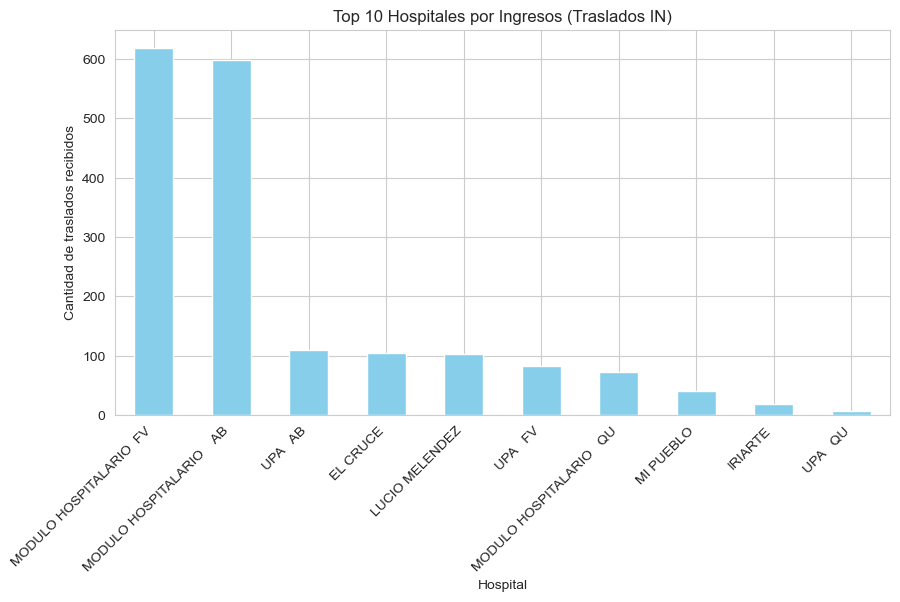

In [18]:
# Traslados OUT (Origen)
traslados_out = bases.traslados_por_hospital(traslados, col_hospital="Nombre Hospital", graficar=False)

# Traslados IN (Destino)
traslados_in = bases.traslados_por_hospital(traslados, col_hospital="Hospital siguiente", graficar=False)

tabla_hospitales = pd.DataFrame({
    "traslados_out": traslados_out,
    "traslados_in": traslados_in,
}).fillna(0)

print("Top 10 hospitales que derivan más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_out", ascending=False).head(10))

print("\nTop 10 hospitales que reciben más pacientes:")
display(tabla_hospitales.sort_values(by="traslados_in", ascending=False).head(10))

# Graficamos los IN
tabla_hospitales["traslados_in"].sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Top 10 Hospitales por Ingresos (Traslados IN)")
plt.ylabel("Cantidad de traslados recibidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [19]:
# ESTO ES STRENGTH O FUERZA
# DEGREE: # de hospitales con los que me conecto

# fuerza/grado = numero promedio de traslados que recibo de un hospital con el que estoy conectado

### 3.2 Tiempo promedio que pasa una persona dentro del hospital

Nombre Hospital
IRIARTE                        13.772472
MÓDULO HOSPITALARIO 8 - LZ     11.882353
MÓDULO HOSPITALARIO 10 - QU     9.776132
OÑATIVIA                        9.376883
MÓDULO HOSPITALARIO 11- FV      8.962939
EL CRUCE                        8.249161
MÓDULO HOSPITALARIO  9 - AB     7.695652
MI PUEBLO                       7.645743
LUCIO MELÉNDEZ                  7.576258
EVITA PUEBLO                    7.329577
Name: Duracion días, dtype: float64

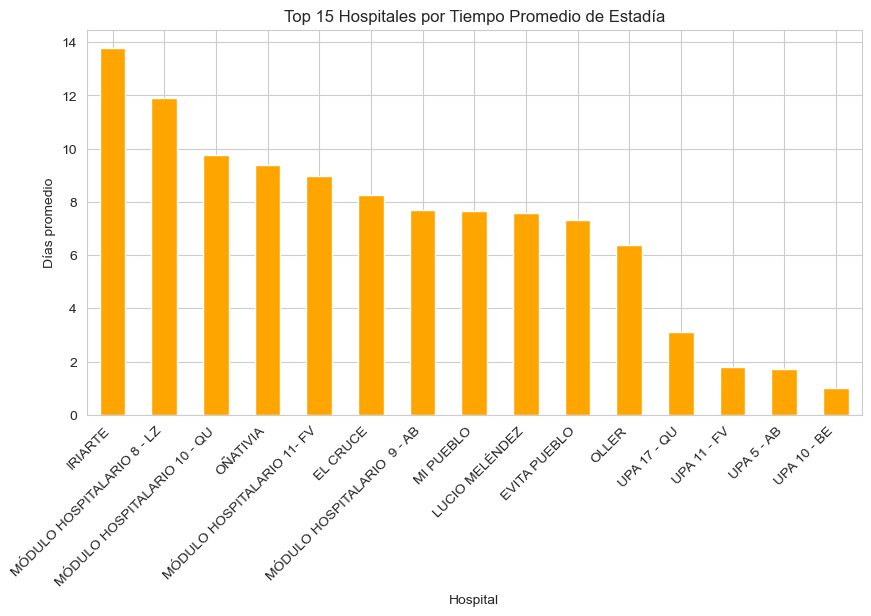

In [20]:
# Tiempo promedio por hospital
tiempo_prom_hosp = bases.tiempo_promedio_por_hospital(df_pacientes, col_hospital="Nombre Hospital", col_dias="Duracion días", quantile_outlier=0.95, graficar=False)

display(tiempo_prom_hosp.head(10))

tiempo_prom_hosp.head(15).plot(kind="bar", color="orange", figsize=(10,5))
plt.title("Top 15 Hospitales por Tiempo Promedio de Estadía")
plt.ylabel("Días promedio")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
# agregar los valores a las barras

### 3.3 Cantidad de muertos por hospital

Nombre Hospital
OÑATIVIA                       595
EVITA PUEBLO                   341
IRIARTE                        323
MI PUEBLO                      311
LUCIO MELÉNDEZ                 308
MÓDULO HOSPITALARIO 11- FV     278
MÓDULO HOSPITALARIO 10 - QU    184
MÓDULO HOSPITALARIO  9 - AB    151
EL CRUCE                       141
UPA 5 - AB                      89
dtype: int64

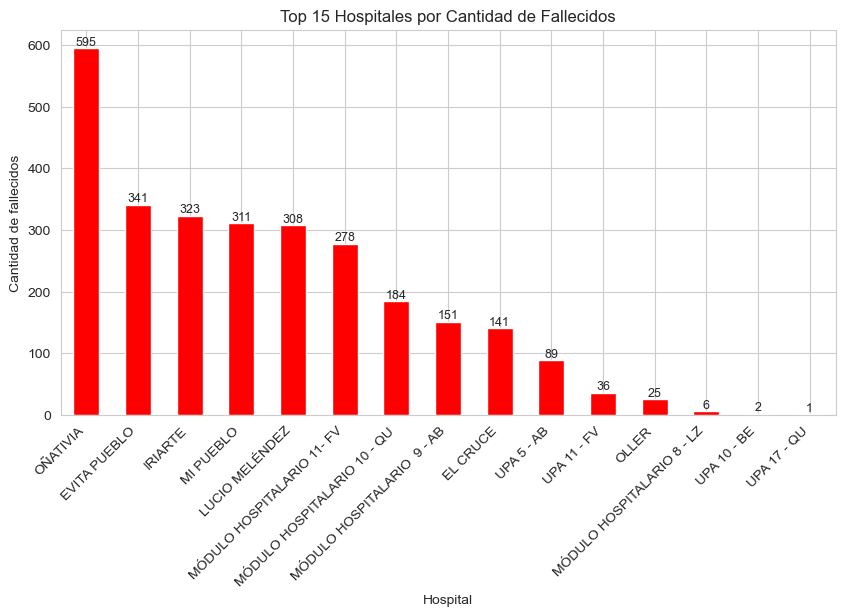

In [22]:
muertes_hosp = bases.muertes_por_hospital(
    df_pacientes,
    col_hospital="Nombre Hospital",
    col_muerte="murio",
    graficar=False
)

display(muertes_hosp.head(10))

ax = muertes_hosp.head(15).plot(kind="bar", color="red", figsize=(10,5))

# agregar numerito arriba de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Top 15 Hospitales por Cantidad de Fallecidos")
plt.ylabel("Cantidad de fallecidos")
plt.xlabel("Hospital")
plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
## entrar a la red o volver a casa o muerte
## version: optimista


# ver que rol tienen estos indicadores en la caminata




In [24]:
## ver los cambios de estado de las personas
## cuanta gente pasa de estado general a critico, intermedio a general, etc etc

## traslados entre hospitales  y traslados entre niveles
# la gente mejora o empeora en el hospital? cuantos?

## 4. Análisis Combinado

### 4.1 Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio general)

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos,Total
Nivel riesgo social,,,,
no,3404,10426,3402,17232
si,2353,1235,2373,5961
Total,5757,11661,5775,23193


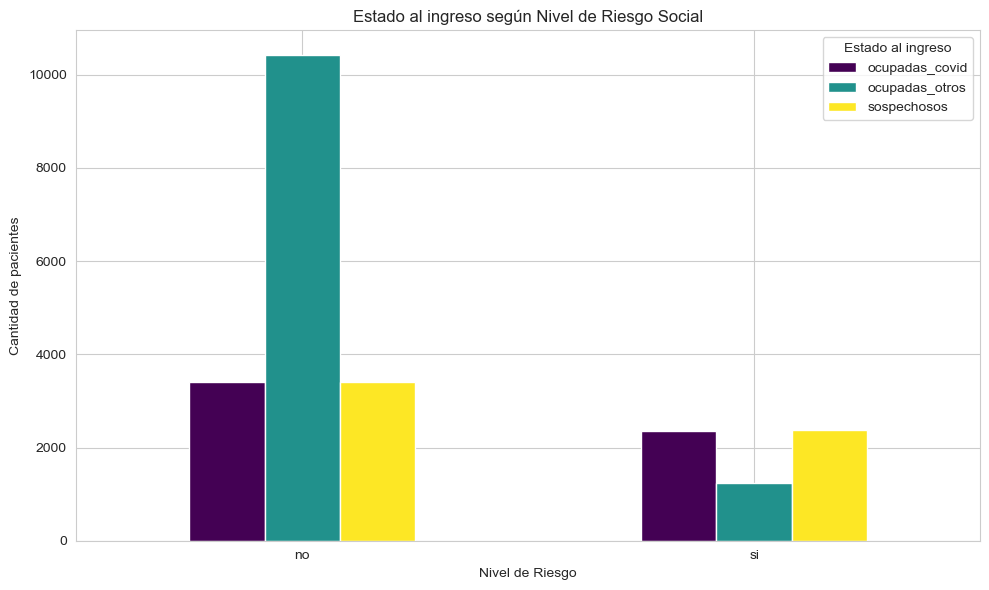

In [25]:
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
# Tabla cruzada de Nivel de riesgo social y Estado al ingreso
if "Nivel riesgo social" in df_pacientes.columns and "Estado al ingreso" in df_pacientes.columns:

    tabla_riesgo_estado = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"],
        margins=True,
        margins_name="Total"
    )

    display(tabla_riesgo_estado)

    tabla_sin_totales = pd.crosstab(
        df_pacientes["Nivel riesgo social"],
        df_pacientes["Estado al ingreso"]
    )

    tabla_sin_totales.plot(
        kind="bar",
        stacked=False,
        figsize=(10,6),
        colormap="viridis"
    )

    plt.title("Estado al ingreso según Nivel de Riesgo Social")
    plt.ylabel("Cantidad de pacientes")
    plt.xlabel("Nivel de Riesgo")
    plt.xticks(rotation=0)
    plt.legend(title="Estado al ingreso")
    plt.tight_layout()
    plt.show()

else:
    print("Las columnas necesarias para este análisis no están disponibles.")
    print("Columnas disponibles:", df_pacientes.columns.tolist())

### 4.2 Relacionar Secciones (Tiempos vs. Riesgo Social / Estado)

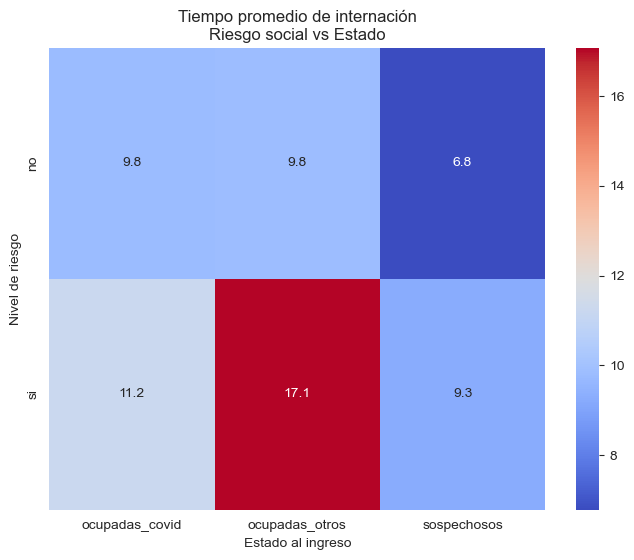

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,9.785965,9.815471,6.783468
si,11.242630,17.071625,9.259243


In [26]:
bases.relacion_tiempo_riesgo_estado(df_pacientes)